# Работа с набором Fashion MNIST

Задача: создать 9 моделей нейронной сети с разными архитектурами, сравнить точность на проверочной и тестовой выборках.

Деление данных:
- обучающая выборка — 50000 изображений;
- проверочная выборка — 10000 изображений;
- тестовая выборка — 10000 изображений.

In [1]:

import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from tensorflow.keras.datasets import fashion_mnist
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Input, Dense, Dropout, BatchNormalization
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.optimizers import Adam

# Отрисовка графиков внутри ноутбука
%matplotlib inline

# Фиксация случайности
np.random.seed(42)
random.seed(42)

In [2]:
class FashionMnistExperiment:
    def __init__(self, epochs=10, batch_size=128):
        self.epochs = epochs
        self.batch_size = batch_size
        self.neuron_list = [32, 64, 128, 256, 512, 1024, 70, 150, 700]

    def load_data(self):
        # Загрузка данных Fashion MNIST
        (x_train_full, y_train_full), (x_test, y_test) = fashion_mnist.load_data()

        # Преобразование изображений 28x28 в вектор
        x_train_full = x_train_full.reshape(60000, 784).astype('float32') / 255.0
        x_test = x_test.reshape(10000, 784).astype('float32') / 255.0

        # Деление исходной обучающей выборки на обучение и проверку
        x_train = x_train_full[:50000]
        y_train = y_train_full[:50000]

        x_val = x_train_full[50000:]
        y_val = y_train_full[50000:]

        # Перевод меток классов в категориальный вид
        y_train = to_categorical(y_train, 10)
        y_val = to_categorical(y_val, 10)
        y_test = to_categorical(y_test, 10)

        return x_train, y_train, x_val, y_val, x_test, y_test

    def create_model(self, neurons):
        # Простая полносвязная нейронная сеть
        model = Sequential([
            Input(shape=(784,)),
            Dense(neurons, activation='relu'),
            BatchNormalization(),
            Dropout(0.2),
            Dense(10, activation='softmax')
        ])

        model.compile(
            optimizer=Adam(learning_rate=0.001),
            loss='categorical_crossentropy',
            metrics=['accuracy']
        )

        return model

    def run(self):
        x_train, y_train, x_val, y_val, x_test, y_test = self.load_data()

        results = []
        histories = {}

        for neurons in self.neuron_list:
            print(f'Обучается модель с количеством нейронов: {neurons}')

            model = self.create_model(neurons)

            trained = model.fit(
                x_train,
                y_train,
                batch_size=self.batch_size,
                epochs=self.epochs,
                validation_data=(x_val, y_val),
                verbose=1
            )

            # Оценка на тестовой выборке
            test_loss, test_accuracy = model.evaluate(x_test, y_test, verbose=0)

            histories[neurons] = trained.history

            results.append({
                'Нейроны': neurons,
                'Точность на обучающей выборке': trained.history['accuracy'][-1],
                'Точность на проверочной выборке': trained.history['val_accuracy'][-1],
                'Точность на тестовой выборке': test_accuracy,
                'Ошибка на обучающей выборке': trained.history['loss'][-1],
                'Ошибка на проверочной выборке': trained.history['val_loss'][-1],
                'Ошибка на тестовой выборке': test_loss
            })

        df = pd.DataFrame(results)
        return df, histories

In [3]:

experiment = FashionMnistExperiment(epochs=10, batch_size=128)
df, histories = experiment.run()

29515/29515 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
26421880/26421880 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
5148/5148 ━━━━━━━━━━━━━━━━━━━━ 0s 1us/step
4422102/4422102 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Обучается модель с количеством нейронов: 32
Epoch 1/10
391/391 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - accuracy: 0.7650 - loss: 0.7072 - val_accuracy: 0.8378 - val_loss: 0.4795
Epoch 2/10
391/391 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.8322 - loss: 0.4869 - val_accuracy: 0.8351 - val_loss: 0.4547
Epoch 3/10
391/391 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.8444 - loss: 0.4445 - val_accuracy: 0.8453 - val_loss: 0.4366
Epoch 4/10
391/391 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.8503 - loss: 0.4209 - val_accuracy: 0.8566 - val_loss: 0.4013
Epoch 5/10
391/391 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - accuracy: 0.8543 - loss: 0.4065 - val_accuracy: 0.8486 - val_loss: 0.4207
Epoch 6/10
391/391 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.8564 - loss: 0.3981 - val_accuracy: 0.8588 - val_loss: 0.4123


In [4]:
# Вывод итоговой таблицы
pd.set_option('display.max_columns', None)
display(df)

,Нейроны,Точность на обучающей выборке,Точность на проверочной выборке,Точность на тестовой выборке,Ошибка на обучающей выборке,Ошибка на проверочной выборке,Ошибка на тестовой выборке
0,32,0.86474,0.8642,0.8554,0.370385,0.378457,0.401785
1,64,0.88190,0.8696,0.8632,0.322984,0.358472,0.384016
2,128,0.88970,0.8555,0.8493,0.298897,0.408517,0.429067
3,256,0.89166,0.8697,0.8645,0.296268,0.357483,0.374929
4,512,0.89094,0.8733,0.8660,0.296245,0.357524,0.386464
5,1024,0.89000,0.8654,0.8611,0.296593,0.380012,0.404924
6,70,0.88342,0.8775,0.8716,0.317484,0.337069,0.359853
7,150,0.88932,0.8510,0.8437,0.299149,0.406475,0.422656
8,700,0.89342,0.8602,0.8510,0.290212,0.399067,0.427521


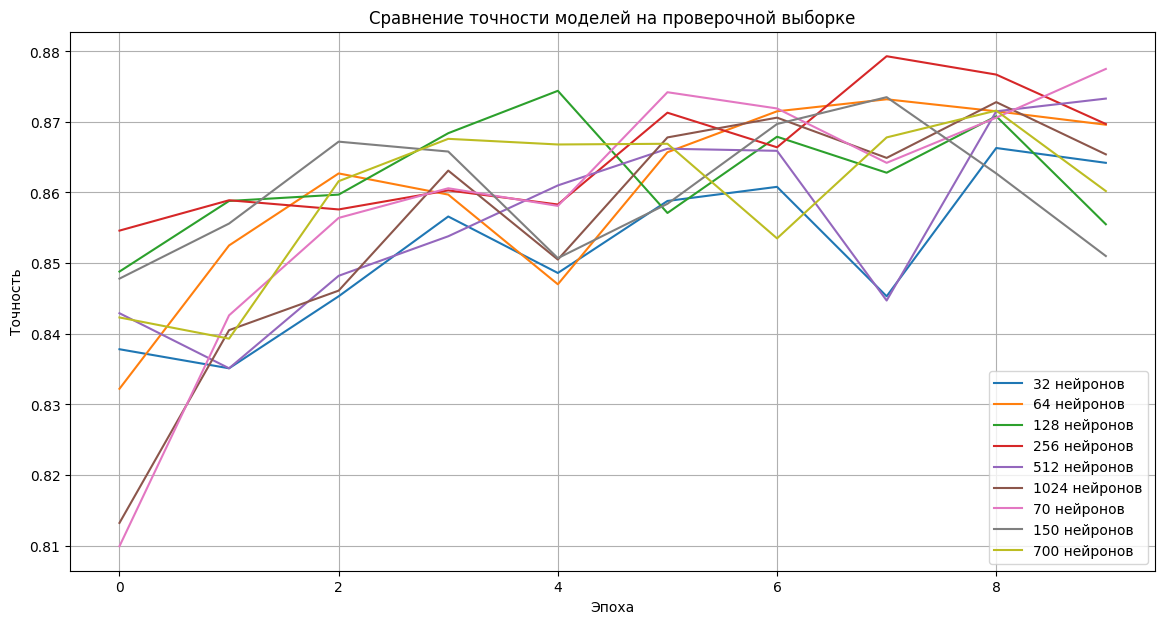

In [5]:
# Общий график точности для всех 9 моделей
plt.figure(figsize=(14, 7))

for neurons in experiment.neuron_list:
    plt.plot(
        histories[neurons]['val_accuracy'],
        label=f'{neurons} нейронов'
    )

plt.title('Сравнение точности моделей на проверочной выборке')
plt.xlabel('Эпоха')
plt.ylabel('Точность')
plt.legend()
plt.grid(True)
plt.show()

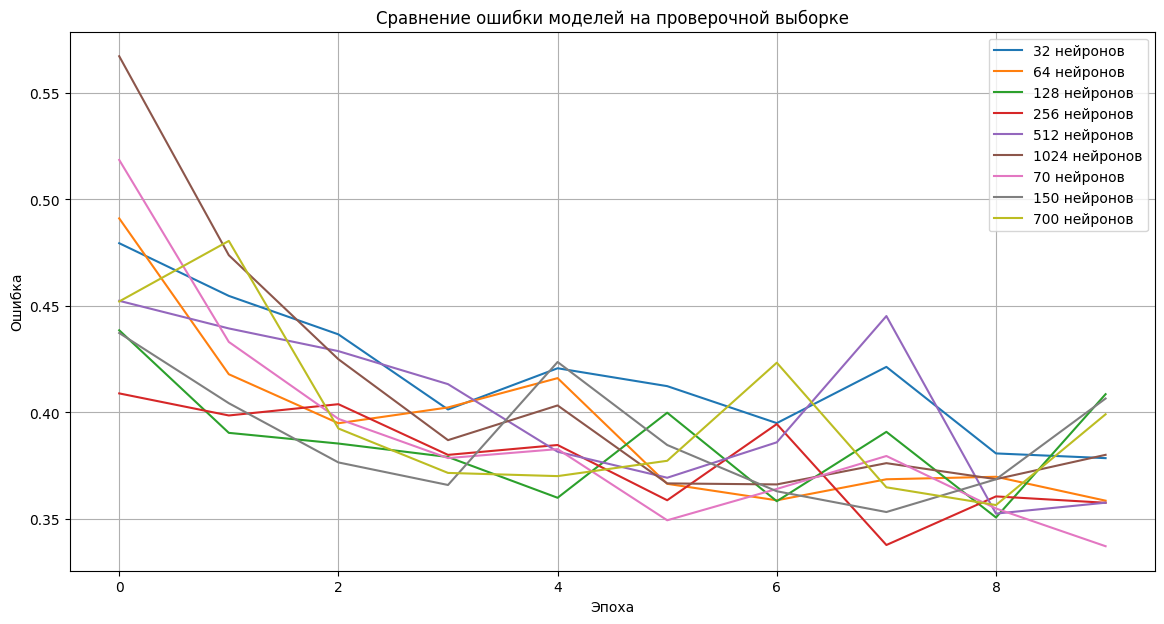

In [6]:
# Общий график функции потерь для всех 9 моделей
plt.figure(figsize=(14, 7))

for neurons in experiment.neuron_list:
    plt.plot(
        histories[neurons]['val_loss'],
        label=f'{neurons} нейронов'
    )

plt.title('Сравнение ошибки моделей на проверочной выборке')
plt.xlabel('Эпоха')
plt.ylabel('Ошибка')
plt.legend()
plt.grid(True)
plt.show()

In [7]:
# Поиск лучшей модели по точности на тестовой выборке
best_row = df.loc[df['Точность на тестовой выборке'].idxmax()]

print('Лучшая модель:')
print(f"Количество нейронов: {int(best_row['Нейроны'])}")
print(f"Точность на проверочной выборке: {best_row['Точность на проверочной выборке']:.4f}")
print(f"Точность на тестовой выборке: {best_row['Точность на тестовой выборке']:.4f}")
print(f"Ошибка на тестовой выборке: {best_row['Ошибка на тестовой выборке']:.4f}")

Лучшая модель:
Количество нейронов: 70
Точность на проверочной выборке: 0.8775
Точность на тестовой выборке: 0.8716
Ошибка на тестовой выборке: 0.3599
